In [4]:
import sys
import os

# 👇 Change this path to the actual directory where SIMPACT_load.py and related files are stored
code_path = "/data3/xyh_desktop/KDD/202601code/final_test"

# Check whether the path exists; if so, add it to the system path
if os.path.exists(code_path):
    if code_path not in sys.path:
        sys.path.append(code_path)
        print(f"✅ Code path successfully added: {code_path}")
else:
    print(f"❌ Path does not exist, please check: {code_path}")


In [5]:
import os
import torch
import scanpy as sc
import pandas as pd
import numpy as np
import anndata as ad
import scipy.sparse as sp
import warnings

# Import your custom modules
# Make sure SIMPACT_load.py, SIMPACT_model.py, etc. are in the current directory
from SIMPACT_load import *
from SIMPACT_model import *
from SIMPACT_eva import *
from SIMPACT_st import *

warnings.filterwarnings('ignore')

# ==========================================
# 1. Define all arguments here (replace argparse)
# ==========================================

# Create a simple class to simulate the args object,
# allowing access via args.variable_name
class Config:
    pass

args = Config()


# --- Required path parameters (replace with your actual paths) ---
args.sc_data_path = "/data/xyh_desktop/AAAI2025/data/WMB-10Xv3-OB-cal.h5ad"   # scRNA-seq data path
args.st_data_path = "/data/xyh_desktop/AAAI2025/data/OB_region_67.h5ad"   # spatial transcriptomics data path

# --- Output directory settings ---
# It is recommended to use relative or absolute paths
base_dir = "/data3/xyh_desktop/KDD/202601desktop/20260117/OB"
args.result_path = os.path.join(base_dir, "results")
args.final_result_path = os.path.join(base_dir, "final_results")
args.eval_path = os.path.join(base_dir, "evaluation")
args.model_path = os.path.join(base_dir, "models")
args.plot_path = os.path.join(base_dir, "plots")

# --- Experiment parameters (following argparse default settings) ---
args.dataset_name = "OB_merfish"
args.anno = "subclass"       # Annotation column name
args.gene_number = 30         # Number of markers per class

# Automatically create all directories to avoid runtime errors
for path in [
    args.result_path,
    args.final_result_path,
    args.eval_path,
    args.model_path,
    args.plot_path
]:
    os.makedirs(path, exist_ok=True)

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Configuration completed. Device: {device}")
print(f"📂 Output directory: {base_dir}")

✅ Configuration completed. Device: cuda
📂 Output directory: /data3/xyh_desktop/KDD/202601desktop/20260117/OB


In [6]:
# ==========================================
# 2. Start main execution logic
# ==========================================

# Extract variables for convenience
anno = args.anno
gene_number = args.gene_number
dataset_name_f = args.dataset_name

result_save_prefix = f"{args.result_path}/init_{dataset_name_f}_{anno}_{gene_number}_"

# --- Load scRNA data ---
print("Loading scRNA data...")
sc_obj = sc.read_h5ad(args.sc_data_path)
sc_obj.var_names = sc_obj.var['gene_symbol'].astype(str)
sc_obj.var_names_make_unique()

# Filter rare categories
counts = sc_obj.obs[anno].value_counts()
sc_obj = sc_obj[sc_obj.obs[anno].isin(counts[counts > 5].index)].copy()

# --- Load ST data ---
print("Loading ST data...")
st_obj = sc.read_h5ad(args.st_data_path)
st_obj.var_names = st_obj.var['gene_symbol'].astype(str)
st_obj.var_names_make_unique()

# ST preprocessing
print("Preprocessing ST data...")
sc.pp.normalize_total(st_obj, target_sum=1e4)
sc.pp.log1p(st_obj)
sc.pp.filter_cells(st_obj, min_counts=20)
sc.pp.filter_genes(st_obj, min_cells=20)

# Load aligned data (fmap_load)
sc_data, st_data = fmap_load(sc_obj, st_obj, anno, gene_number)

# --- Prepare initial training mask ---
print("Building initial marker mask...")
num_classes = len(set(sc_data.obs[anno]))
# Note: please confirm whether the key in .uns is 'csg' or 'cosg'
markers_df = pd.DataFrame(sc_data.uns["csg"]["names"]).iloc[0:num_classes * gene_number, :]
input_size = sc_data.X.shape[1]
top_k = gene_number
marker_mask = torch.zeros(num_classes, input_size)
gene2idx = {g: i for i, g in enumerate(sc_data.var_names)}

for ct_idx, ct in enumerate(markers_df.columns):
    genes_ct = markers_df[ct].head(top_k).dropna().tolist()
    idx = [gene2idx[g] for g in genes_ct if g in gene2idx]
    marker_mask[ct_idx, idx] = 1.0

# --- Stage 1: Initial model training ---

fmap_train_retrain_st1(
    sc_data,
    st_data,
    result_save_prefix,
    num_classes,
    anno,
    marker_mask,
    num_epochs=100
)

# --- Compute group means for evaluation ---
print("Computing group means...")
df_grouped_means = pd.DataFrame(index=sc_data.obs[anno].cat.categories,
                                columns=sc_data.var_names)
for annotation in sc_data.obs[anno].unique():
    subset = sc_data[sc_data.obs[anno] == annotation, :]
    # Handle sparse matrix case
    if sp.issparse(subset.X):
        mean_expression = subset.X.mean(axis=0).A1
    else:
        mean_expression = subset.X.mean(axis=0)
    df_grouped_means.loc[annotation] = mean_expression

# --- Evaluate initial results for 10 runs ---
print("Evaluating initial results...")
for i in range(10):
    result_path = f"{args.result_path}/init_{dataset_name_f}_{anno}_{gene_number}_{i}.csv"
    output_path = f"{args.eval_path}/init_{dataset_name_f}_{gene_number}{i}_all_values{gene_number}.csv"

    if os.path.exists(result_path):
        evaluate_prediction_vs_reference(
            result_path,
            df_grouped_means,
            st_data,
            output_path,
            anno_col="annotation"
        )

# --- Select Top 3 runs ---
print("Selecting best Top 3 runs...")
top3_rounds_vec = evaluate_and_rank_predictions(
    root_dir=args.eval_path,
    dataset_name="init_" + dataset_name_f,
    gene_number=gene_number,
    pattern=os.path.join(args.eval_path, f"*_average_values_{gene_number}.csv")
)
print(f"Top 3 rounds: {top3_rounds_vec}")

# --- Build spatial neighborhood data ---
print("Building spatial neighborhood data (concat_self_neighbor_expression)...")
adata_new = concat_self_neighbor_expression(
    adata=st_data,
    x_key="x",
    y_key="y",
    k=15,
    include_self=False,
    layer=None,
    layer_key_for_raw="raw_counts"
)

# --- Fuse Top 3 results as pseudo-labels ---
print("Fusing pseudo-labels...")
sc_data_st_final = None
for round_id in top3_rounds_vec:
    csv_path = f"{args.result_path}/init_{dataset_name_f}_{anno}_{gene_number}_{round_id}.csv"
    if not os.path.exists(csv_path):
        continue

    result = pd.read_csv(csv_path)
    conf = result.max(axis=1)
    predicted_labels = result.idxmax(axis=1)
    adata_new.obs[anno] = predicted_labels.values
    sc_data_st = adata_new[adata_new.obs[anno] != 'filter'].copy()

    if sc_data_st_final is None:
        sc_data_st_final = sc_data_st
    else:
        sc_data_st_final = ad.concat([sc_data_st_final, sc_data_st])

print(f"Final training set size: {sc_data_st_final.shape}")

# --- Prepare final masks (marker & anti-marker) ---
print("Preparing final masks (marker & anti-marker)...")
# Re-align markers
markers_df = pd.DataFrame(sc_data.uns["csg"]["names"]).iloc[0:num_classes * gene_number, :]
marker_genes = set(markers_df.values.flatten().tolist())
valid_types = set(sc_data_st_final.obs[anno])

markers_df = markers_df.loc[:, markers_df.columns.isin(valid_types)]
num_classes = len(set(sc_data_st_final.obs[anno]))
input_size = sc_data_st_final.X.shape[1]
top_k = gene_number

# Positive marker mask
marker_mask = torch.zeros(num_classes, input_size)  # (C, G)
gene2idx = {g: i for i, g in enumerate(sc_data_st_final.var_names)}
for ct_idx, ct in enumerate(markers_df.columns):
    genes_ct = markers_df[ct].head(top_k).dropna().tolist()
    idx = [gene2idx[g] for g in genes_ct if g in gene2idx]
    marker_mask[ct_idx, idx] = 1.0

# Anti-marker mask (inverse CSG)
print("Computing anti-markers...")
inverse_csg(
    sc_data_st_final,
    groupby=anno
)
anti_df = pd.DataFrame(sc_data_st_final.uns["csg_inv"]["names"])
anti_df = anti_df.loc[:, anti_df.columns.isin(set(sc_data_st_final.obs[anno]))]

anti_mask = torch.zeros(num_classes, input_size)
for ct_idx, ct in enumerate(anti_df.columns):
    genes_ct = anti_df[ct].head(top_k).dropna().tolist()
    idx = [gene2idx[g] for g in genes_ct if g in gene2idx]
    anti_mask[ct_idx, idx] = 1.0

# --- Stage 2: Final training ---
result_save = f"{args.final_result_path}/SIMPACT_{dataset_name_f}_{gene_number}_{anno}_"
model_save = f"{args.model_path}/SIMPACT_{dataset_name_f}_{gene_number}_{anno}_"
plot_save = f"{args.plot_path}/SIMPACT_{dataset_name_f}_{gene_number}_{anno}_"


fmap_train_retrain_st2(
    sc_data_st_final,
    adata_new,
    result_save,
    model_save,
    plot_save,
    num_classes,
    anno,
    marker_mask,
    anti_mask,
    num_epochs=200
)

print("🎉 All tasks completed successfully!")

Loading scRNA data...
Loading ST data...
Preprocessing ST data...
csg_first
488
start
end
Total time: 3.935 s
427
Building initial marker mask...
Computing group means...
Evaluating initial results...
Selecting best Top 3 runs...
Top 3 rounds: [2 5 9]
Building spatial neighborhood data (concat_self_neighbor_expression)...
Fusing pseudo-labels...
Final training set size: (87732, 854)
Preparing final masks (marker & anti-marker)...
Computing anti-markers...
🎉 All tasks completed successfully!


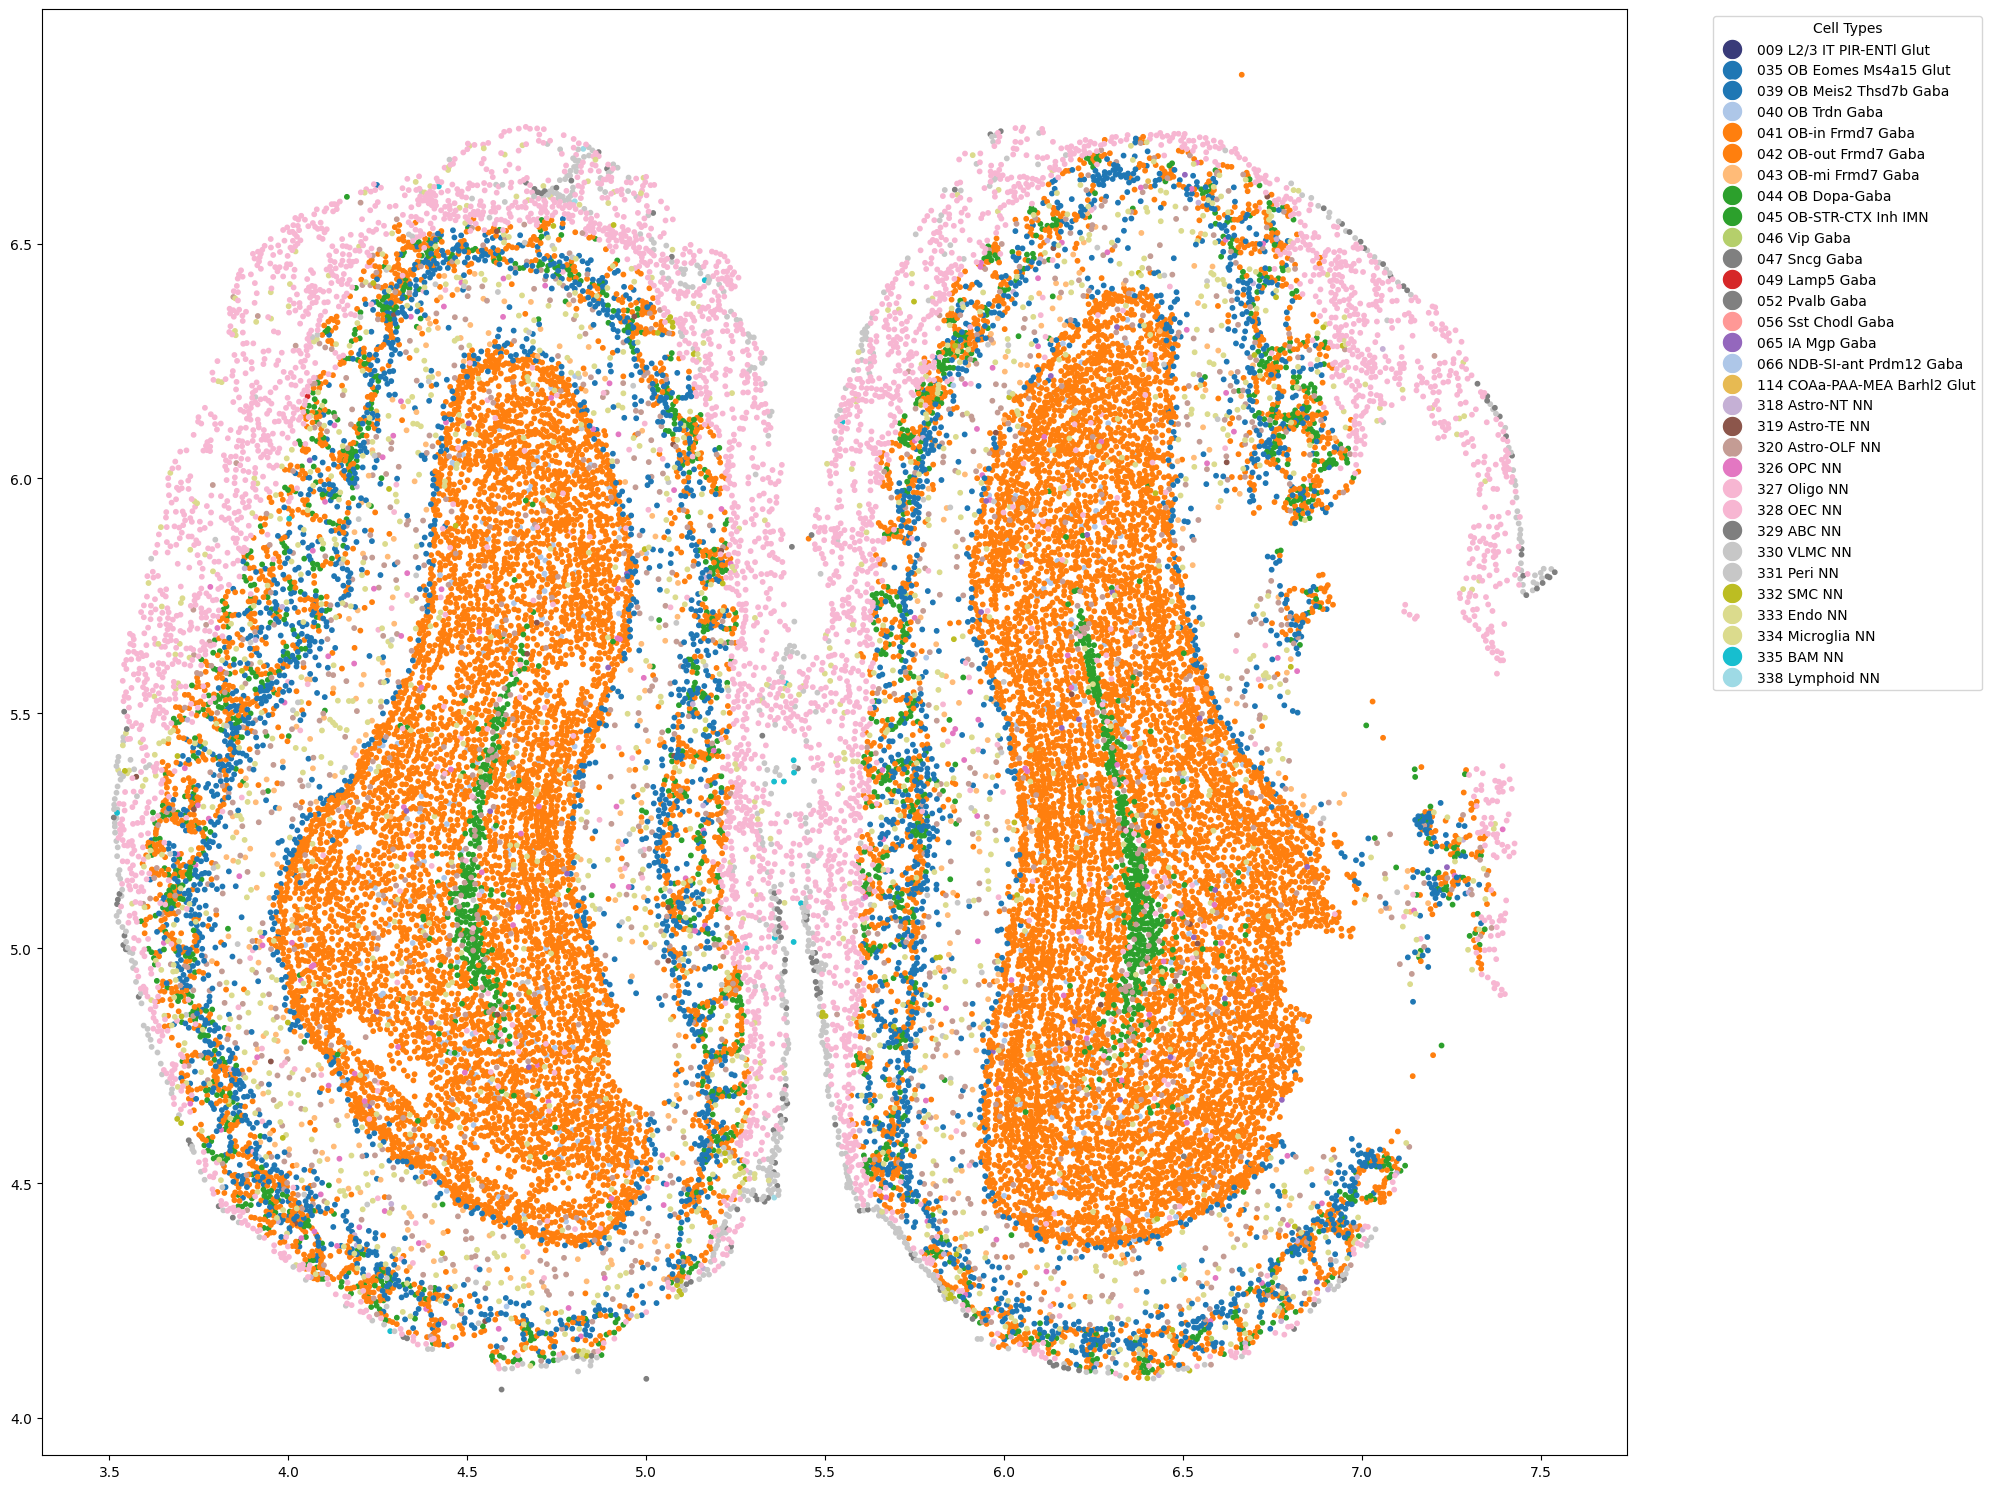

saved to: /data3/xyh_desktop/KDD/202601desktop/20260117/OB/plots/SIMPACT_OB_merfish_30_subclass_.pdf


In [7]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
import numpy as np


result_name='/data3/xyh_desktop/KDD/202601desktop/20260117/OB/results/SIMPACT_OB_merfish_30_subclass_0.csv'
df = pd.read_csv(result_name)
pred = df.idxmax(axis=1).astype(str)

st_data.obs['predicted_classes']=pred
st_data.obs['predicted_classes'] = pred.values
unique_clusters = np.unique(st_data.obs[anno])
unique_predictions = np.unique(st_data.obs['predicted_classes'])
cmap_clusters = plt.get_cmap('tab20', len(unique_clusters))
cmap_predictions = plt.get_cmap('tab20b', len(unique_predictions)) 
color_map = {label: cmap_clusters(i) for i, label in enumerate(unique_clusters)}
color_map.update({label: cmap_predictions(i) for i, label in enumerate(unique_predictions) if label not in color_map})


special_colors = {
'066 NDB-SI-ant Prdm12 Gaba':  '#aec7e8',  
'075 MEA-BST Lhx6 Nr2e1 Gaba':    '#ff7f0e',
'036 HPF CR Glut':    '#c85e0b',  
'038 DG-PIR Ex IMN':      "#2ca02c",
'064 STR-PAL Chst9 Gaba':     "#ffff00",
'061 STR D1 Gaba':  '#aec7e8',
'080 CEA-AAA-BST Six3 Sp9 Gaba':  'gray',
'052 Pvalb Gaba':  'gray',
'047 Sncg Gaba':  'gray',
}
color_map.update(special_colors)

colors = [color_map[label] for label in st_data.obs['predicted_classes']]

subset_color_map = {label: color_map[label] for label in unique_predictions if label in color_map}
coor_x = st_data.obs['x']
coor_y = st_data.obs['y']


fig, ax = plt.subplots(figsize=(20, 15))
scatter = ax.scatter(coor_x, coor_y, c=colors, s=10)
legend_elements = [Line2D([0], [0], marker='o', color='w', label=cell_type, 
                          markerfacecolor=color, markersize=15) 
                   for cell_type, color in subset_color_map.items()]

ax.legend(handles=legend_elements, title='Cell Types', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
save_path = plot_save + ".pdf"
plt.savefig(save_path, format='pdf', bbox_inches='tight', dpi=300)

plt.show()
print(f"saved to: {save_path}")
